# Anomaly Investigation: Latency (psp_gamma incident) & Systematic Category x Time Scan

Standalone notebook — reloads and prepares the data independently of `01_eda.ipynb`.

Goal: check whether `bank_id == 777` (see `02_anomaly_bank_id_777.ipynb`) is the only artificially inserted group, or whether other hidden clusters exist across the full dataset. Moves from a single distribution (latency) to a systematic scan across every category x time window.


In [1]:
import pandas as pd

df = pd.read_csv('/home/veronika/Anomaly_Hunter_Solidgate/hackathon_int20h_dataset_test.csv')

In [2]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['processed_at'] = pd.to_datetime(df['processed_at'])

## 7. Latency across the full dataset

Goal: check whether `bank_id == 777` is the only artificially inserted group, or whether other hidden clusters with their own constant latency exist (635 rows out of 1M are statistically invisible in aggregate stats).

In [3]:
duration = df['processed_at'] - df['created_at']
print(duration.nunique())
print(duration.describe())

2849
count                      1000000
mean        0 days 00:00:35.362397
std      0 days 00:06:44.623737607
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:59
dtype: object


In [4]:
for id in df['bank_id'].unique():
    i = df[df['bank_id'] == id]
    duration = i['processed_at'] - i['created_at']
    print(duration.nunique())
    print(duration.describe())

123
count                        20257
mean     0 days 00:00:37.192920965
std      0 days 00:06:59.486361362
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:57
dtype: object
124
count                        20687
mean     0 days 00:00:35.787209358
std      0 days 00:06:42.800718590
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:30
dtype: object
109
count                        20708
mean     0 days 00:00:33.617925439
std      0 days 00:06:33.026824349
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:50
dtype: object
111
count                        20373
mean     0 days 00:00:34.538801354
std      0 days 00:06:41.9717869

130
count                        20571
mean     0 days 00:00:38.409216858
std      0 days 00:07:06.844806947
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:47
dtype: object
117
count                        20443
mean     0 days 00:00:34.687374651
std      0 days 00:06:38.879498434
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:38
dtype: object
111
count                        20264
mean     0 days 00:00:32.806602842
std      0 days 00:06:24.516478998
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:27
dtype: object
121
count                        20330
mean     0 days 00:00:37.221446138
std      0 days 00:06:58.1505500

127
count                        20255
mean     0 days 00:00:37.983263391
std      0 days 00:07:02.561911837
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:38
dtype: object
110
count                        20399
mean     0 days 00:00:33.075886072
std      0 days 00:06:26.930278502
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:42
dtype: object
130
count                        20375
mean     0 days 00:00:37.794503067
std      0 days 00:06:57.374006477
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:55
dtype: object
109
count                        20237
mean     0 days 00:00:33.064831743
std      0 days 00:06:27.3514079

117
count                        20258
mean     0 days 00:00:34.968604995
std      0 days 00:06:39.085969559
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:13
dtype: object
100
count                        20297
mean     0 days 00:00:31.264029166
std      0 days 00:06:17.767533575
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:39
dtype: object
110
count                        20462
mean     0 days 00:00:33.033085719
std      0 days 00:06:27.062740337
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:58:36
dtype: object
120
count                        20471
mean     0 days 00:00:35.750915929
std      0 days 00:06:50.8806380

102
count                        20503
mean     0 days 00:00:31.305174852
std      0 days 00:06:20.357143876
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:58:30
dtype: object
133
count                        20481
mean     0 days 00:00:38.844734143
std      0 days 00:07:06.708449977
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:58:22
dtype: object
132
count                        20405
mean     0 days 00:00:39.526390590
std      0 days 00:07:15.211827267
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:59
dtype: object
103
count                        20190
mean     0 days 00:00:32.022387320
std      0 days 00:06:27.4199155

128
count                        20599
mean     0 days 00:00:37.760862177
std      0 days 00:06:58.863735382
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:58:31
dtype: object
114
count                        20313
mean     0 days 00:00:34.396248707
std      0 days 00:06:38.192624822
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:40
dtype: object
103
count                        20454
mean     0 days 00:00:31.154884130
std      0 days 00:06:14.215725286
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:57:59
dtype: object
135
count                        20757
mean     0 days 00:00:38.789757672
std      0 days 00:07:06.1005238

count                        20429
mean     0 days 00:00:36.124235155
std      0 days 00:06:51.889305535
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:55
dtype: object
129
count                        20520
mean     0 days 00:00:38.920224171
std      0 days 00:07:14.396242212
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:59:57
dtype: object
115
count                        20143
mean     0 days 00:00:34.131311125
std      0 days 00:06:31.429922027
min                0 days 00:00:02
25%                0 days 00:00:04
50%                0 days 00:00:06
75%                0 days 00:00:08
max                0 days 01:58:53
dtype: object
114
count                        20746
mean     0 days 00:00:33.147353706
std      0 days 00:06:26.571943950
m

## 8. Finding hidden latency clusters

`describe()` on the full dataset cannot reveal distribution shape - the 635 rows of `bank_id == 777` are statistically invisible among a million. Finding further hidden clusters requires visualizing the shape of the distribution, not just summary numbers.

In [5]:
import matplotlib.pyplot as plt

duration = df['processed_at'] - df['created_at']
duration = duration.dt.total_seconds()

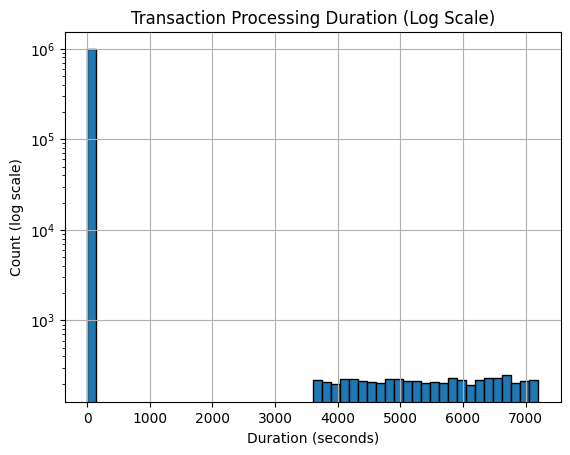

In [6]:
duration.hist(bins=50, edgecolor='black', log=True)

plt.title('Transaction Processing Duration (Log Scale)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count (log scale)')
plt.show()

**Finding:** the log scale immediately shows a non-unimodal distribution - a mass of fast transactions plus a separate, much smaller cluster somewhere in the range of hours. On a linear scale, the second cluster would be invisible.

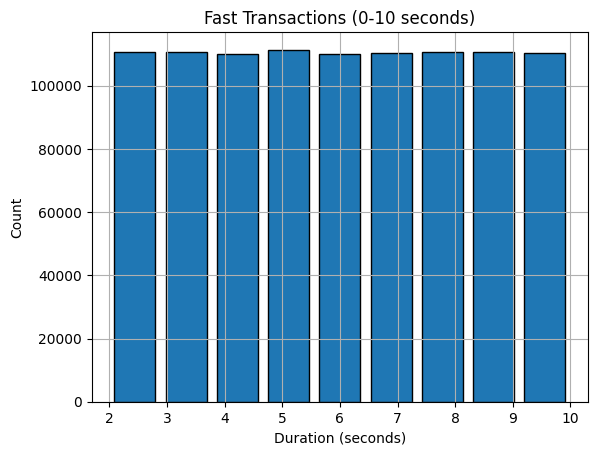

In [7]:
duration_fast = duration[duration <= 10]
duration_fast.hist(bins=9, edgecolor='black', rwidth=0.8)

plt.title('Fast Transactions (0-10 seconds)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.xticks(range(2, 11))

plt.show()

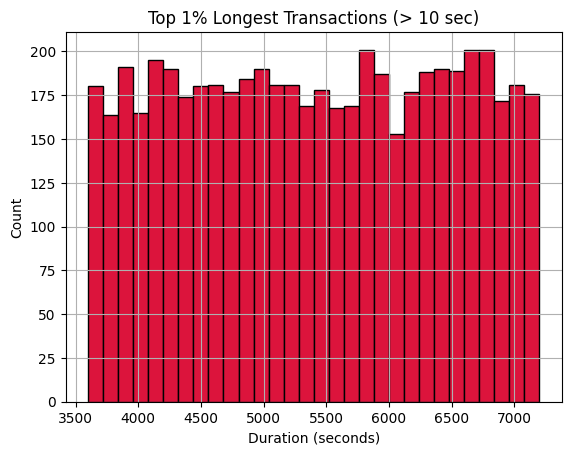

In [8]:
q_99 = duration.quantile(0.99)
anomalies = duration[duration > q_99]
anomalies.hist(bins=30, edgecolor='black', color='crimson')

plt.title(f'Top 1% Longest Transactions (> {int(q_99)} sec)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.show()

In [9]:
fast = duration[duration <= 10].count()
mid = duration[(duration > 10) & (duration <= 3600)].count()
long_1_2h = duration[(duration > 3600) & (duration <= 7200)].count()
hardcore = duration[duration > 7200].count()

total = duration.count()

print("--- TRANSACTION DURATION BREAKDOWN ---")
print(f"Under 10 seconds:        {fast:<10} ({fast/total*100:.4f}%)")
print(f"10 seconds - 1 hour:     {mid:<10} ({mid/total*100:.4f}%)")
print(f"1 hour - 2 hours:        {long_1_2h:<10} ({long_1_2h/total*100:.4f}%)")
print(f"Over 2 hours:            {hardcore:<10} ({hardcore/total*100:.4f}%)")
print("---------------------------------------")
print(f"Total:                   {total}")

--- TRANSACTION DURATION BREAKDOWN ---
Under 10 seconds:        994567     (99.4567%)
10 seconds - 1 hour:     0          (0.0000%)
1 hour - 2 hours:        5433       (0.5433%)
Over 2 hours:            0          (0.0000%)
---------------------------------------
Total:                   1000000


**Key result:** a clean gap in the distribution:
- < 10 seconds: 994,567 transactions (the vast majority);
- 10 seconds - 1 hour: **0 transactions** (complete gap);
- 1-2 hours: 5,433 transactions;
- > 2 hours: **0 transactions**.

A sharp gap with no intermediate values is the signature of **two separate processes** mixed into one column, not a single heavy-tailed distribution. The threshold for investigation is chosen at the percentile boundary (> 1 hour).

In [10]:
check_direction = df[(df['processed_at'] - df['created_at']).dt.total_seconds() >= 3600]
check_direction

,created_at,order_id,processed_at,order_type,user_id,ip_country,currency,amount,payment_method,order_payment_type,bin_country,bank_id,psp_id,has_refund,refunded_amount,is_secured,status,error_code
680,2025-05-12 04:28:32,681,2025-05-12 06:09:37,recurring,874634,FRA,EUR,18.40,card,retry,FRA,37,psp_gamma,False,0.0,False,success,NaN
775,2025-05-13 12:29:03,776,2025-05-13 13:33:33,recurring,684060,USA,USD,30.00,card,1-click,USA,32,psp_gamma,False,0.0,False,fail,2.12
1495,2025-05-15 16:55:37,1496,2025-05-15 18:11:58,first,378505,USA,USD,10.00,card,NaN,USA,4,psp_gamma,False,0.0,False,fail,3.08
1826,2025-05-12 23:13:37,1827,2025-05-13 00:19:04,first,734329,USA,USD,1.00,card,NaN,USA,24,psp_gamma,False,0.0,False,success,NaN
2334,2025-05-15 09:50:47,2335,2025-05-15 10:56:27,first,516546,FRA,EUR,9.19,card,NaN,FRA,41,psp_gamma,False,0.0,True,success,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998803,2025-05-17 20:51:45,998804,2025-05-17 22:34:43,first,131958,USA,USD,19.99,card,NaN,FRA,32,psp_gamma,False,0.0,False,fail,3.04
998856,2025-05-14 13:48:57,998857,2025-05-14 15:06:15,recurring,183537,UKR,UAH,2472.00,card,1-click,UKR,8,psp_gamma,False,0.0,False,success,NaN
999020,2025-05-16 12:34:35,999021,2025-05-16 14:33:16,first,737268,USA,USD,5.00,googlepay,NaN,USA,19,psp_gamma,False,0.0,False,success,NaN
999186,2025-05-15 23:03:41,999187,2025-05-16 00:17:11,first,181419,DEU,EUR,4.60,card,NaN,DEU,3,psp_gamma,False,0.0,False,fail,4.09


In [11]:
print(check_direction.nunique())

created_at            5399
order_id              5433
processed_at          5408
order_type               2
user_id               5412
ip_country               8
currency                 7
amount                 110
payment_method           3
order_payment_type       4
bin_country              8
bank_id                 49
psp_id                   1
has_refund               2
refunded_amount         52
is_secured               2
status                   2
error_code              13
dtype: int64


In [12]:
for col in check_direction.columns:
    print(check_direction[col].value_counts())
    print("\n")

created_at
2025-05-12 15:07:05    2
2025-05-13 21:47:06    2
2025-05-14 10:58:14    2
2025-05-14 07:06:21    2
2025-05-17 21:48:11    2
                      ..
2025-05-16 02:56:46    1
2025-05-17 21:17:58    1
2025-05-16 15:31:10    1
2025-05-14 20:14:44    1
2025-05-14 09:41:50    1
Name: count, Length: 5399, dtype: int64


order_id
681       1
681424    1
684322    1
684260    1
684237    1
         ..
344887    1
344682    1
344644    1
344444    1
999199    1
Name: count, Length: 5433, dtype: int64


processed_at
2025-05-14 02:53:52    2
2025-05-14 20:35:15    2
2025-05-12 22:03:44    2
2025-05-16 10:59:15    2
2025-05-13 13:57:46    2
                      ..
2025-05-15 02:41:57    1
2025-05-16 11:24:57    1
2025-05-16 23:33:20    1
2025-05-14 07:31:30    1
2025-05-14 11:22:18    1
Name: count, Length: 5408, dtype: int64


order_type
recurring    3314
first        2119
Name: count, dtype: int64


user_id
200834    2
915867    2
329255    2
124109    2
289883    2
         ..
2982

**Profile of the cluster (>= 1 hour):**
- 100% of rows have `psp_id == psp_gamma` - the entire anomaly is tied to one payment provider;
- `status`/`error_code` show a mix of success/fail (2902/2531) with no clear dominant outcome - the delay itself does not force a failure. Exact comparison: fail rate in the cluster = 2531/5433 ~ 46.59%, fail rate across the whole dataset = 474886/1000000 ~ 47.49% - essentially the same. The delay does not raise the failure risk; the provider eventually succeeded or failed at the normal rate, just slower.

In [13]:
check_direction['created_date'] = check_direction['created_at'].dt.date
check_direction['processed_date'] = check_direction['processed_at'].dt.date

/tmp/ipykernel_965662/802721025.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  check_direction['created_date'] = check_direction['created_at'].dt.date
/tmp/ipykernel_965662/802721025.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  check_direction['processed_date'] = check_direction['processed_at'].dt.date


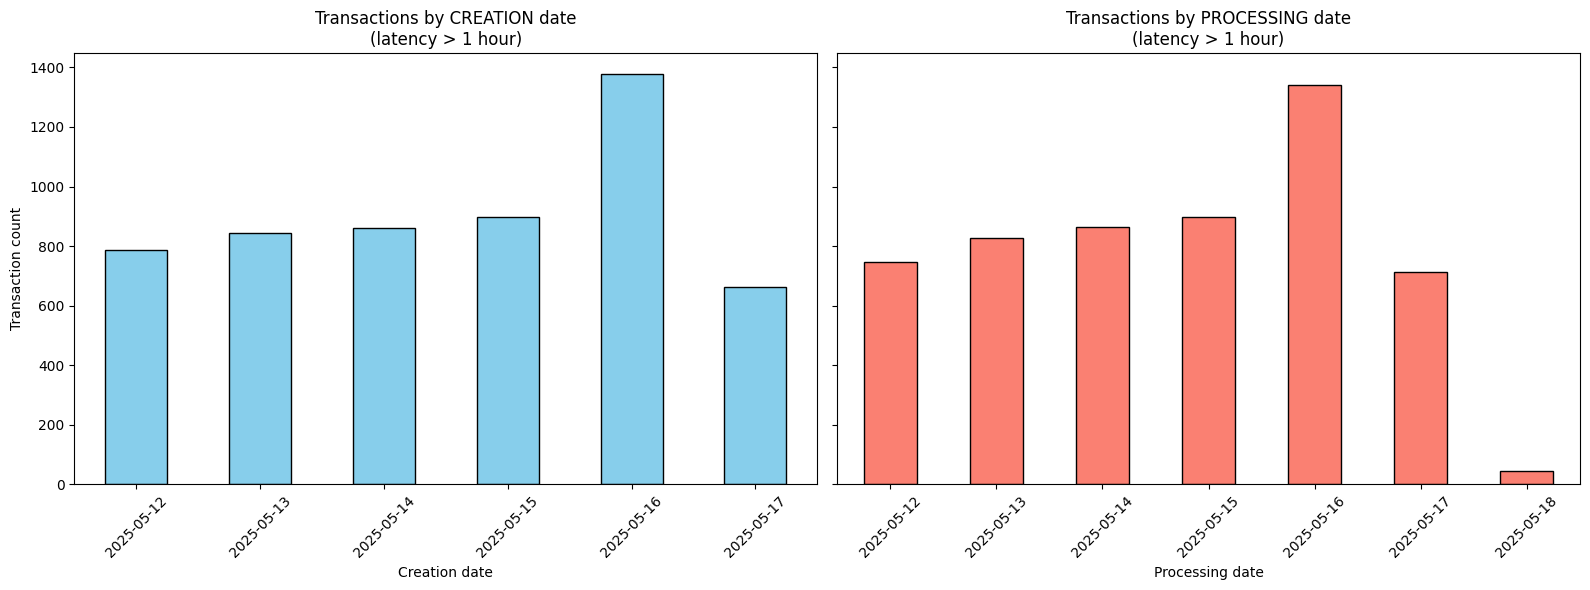

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
check_direction = check_direction.sort_values('created_at')

check_direction['created_date'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='skyblue', edgecolor='black'
)
axes[0].set_title('Transactions by CREATION date\n(latency > 1 hour)')
axes[0].set_xlabel('Creation date')
axes[0].set_ylabel('Transaction count')
axes[0].tick_params(axis='x', rotation=45)

check_direction['processed_date'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='salmon', edgecolor='black'
)
axes[1].set_title('Transactions by PROCESSING date\n(latency > 1 hour)')
axes[1].set_xlabel('Processing date')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Temporal shape:** transactions were created exclusively between **May 12-17, 2025**, peaking (worst) on May 16 and recovering by the 17th - a gradual degrade/recover shape, not an instant on/off switch. This is typical of a real operational incident, unlike the single-day artificial block of `bank_id == 777`.

In [15]:
start_date = '2025-05-12 00:00:00'
end_date = '2025-05-17 23:59:59'

provider_df = df[
    (df['psp_id'] == 'psp_gamma') &
    (df['created_at'] >= start_date) &
    (df['created_at'] <= end_date)
].copy()

duration_provider = provider_df['processed_at'] - provider_df['created_at']
duration_seconds = duration_provider.dt.total_seconds()

total_provider_tx = provider_df.shape[0]
anomalies_provider = duration_seconds[duration_seconds >= 3600].count()
normal_provider = duration_seconds[duration_seconds < 3600].count()

print("=== PSP_GAMMA STATISTICS (12-17 May 2025) ===")
print(f"Total transactions created:  {total_provider_tx}")
print(f"Normal (< 1 hour):            {normal_provider} ({normal_provider / total_provider_tx * 100:.2f}%)")
print(f"Delayed (>= 1 hour):          {anomalies_provider} ({anomalies_provider / total_provider_tx * 100:.2f}%)")
print("==============================================")

=== PSP_GAMMA STATISTICS (12-17 May 2025) ===
Total transactions created:  5433
Normal (< 1 hour):            0 (0.00%)
Delayed (>= 1 hour):          5433 (100.00%)


## 9. Systematic category x time scan

`pivot_table` + heatmap (`psp_id`/`bank_id` x week) scans latency and fail-rate across every category at once, instead of manually filtering one category at a time.

In [16]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [17]:
import seaborn as sns

df['latency_sec'] = (df['processed_at'] - df['created_at']).dt.total_seconds()
df['week'] = df['created_at'].dt.to_period('W').astype(str)

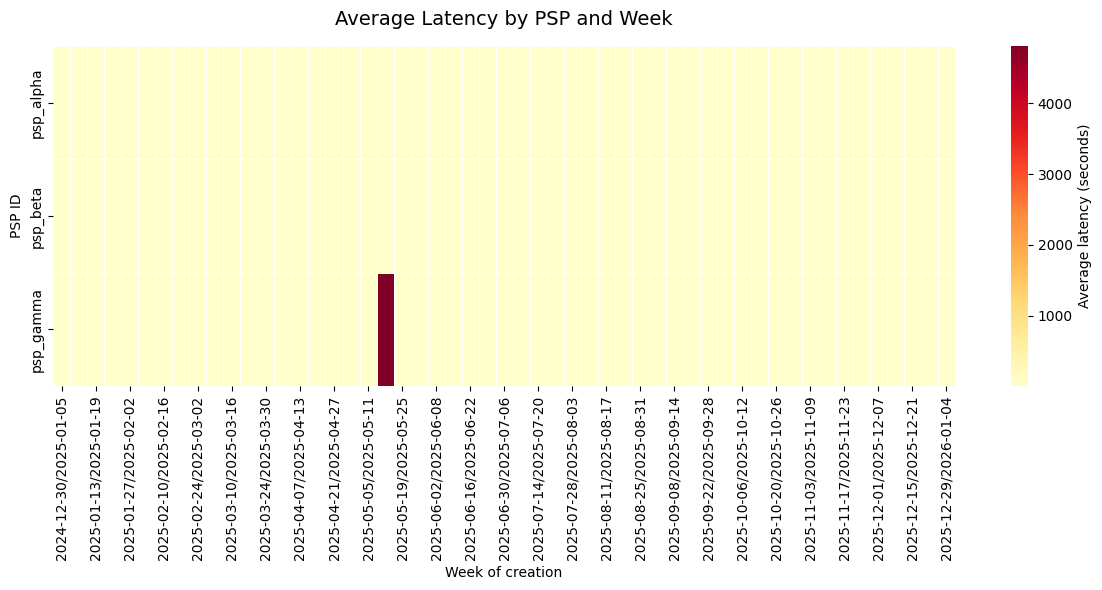

In [18]:
pivot_df = df.pivot_table(values='latency_sec', index='psp_id', columns='week', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_df,
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Average latency (seconds)'}
)
plt.title('Average Latency by PSP and Week', fontsize=14, pad=15)
plt.xlabel('Week of creation')
plt.ylabel('PSP ID')
plt.tight_layout()
plt.show()

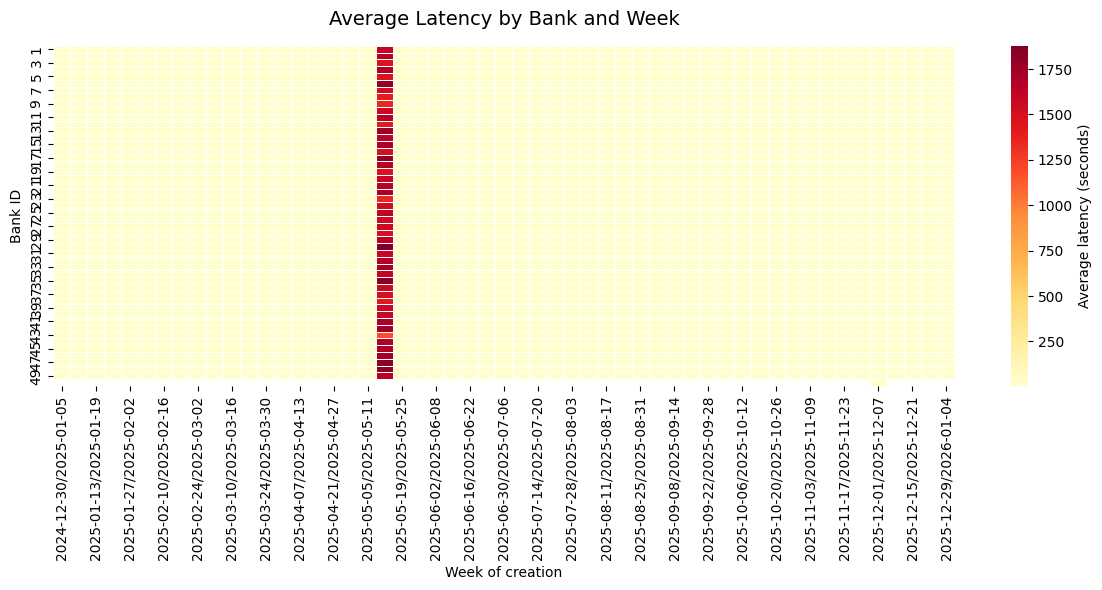

In [19]:
pivot_df = df.pivot_table(values='latency_sec', index='bank_id', columns='week', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_df,
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Average latency (seconds)'}
)
plt.title('Average Latency by Bank and Week', fontsize=14, pad=15)
plt.xlabel('Week of creation')
plt.ylabel('Bank ID')
plt.tight_layout()
plt.show()

**Conclusion:** for latency, no `bank_id` shows an anomalous window of its own except `bank_id == 777` - its row is only "hot" in the week of 2025-12-01/12-07 (since all 635 rows were created then), and empty everywhere else. No new finding here - this is the same cluster from section 6.

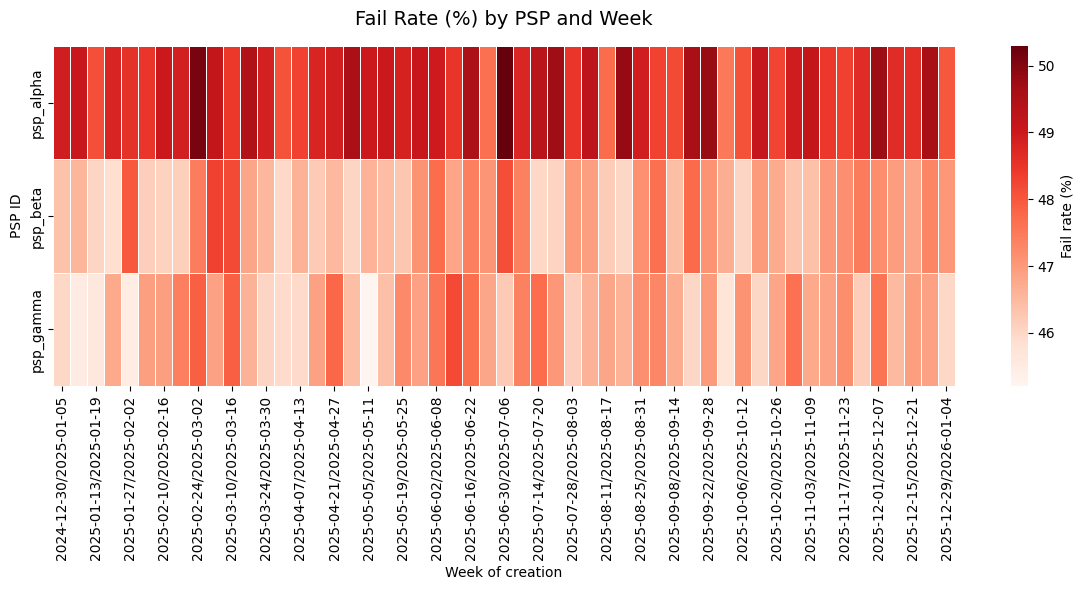

In [20]:
df['is_fail'] = (df['status'] == 'fail').astype(int)

pivot_df = df.pivot_table(values='is_fail', index='psp_id', columns='week', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_df * 100,
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={'label': 'Fail rate (%)'}
)
plt.title('Fail Rate (%) by PSP and Week', fontsize=14, pad=15)
plt.xlabel('Week of creation')
plt.ylabel('PSP ID')
plt.tight_layout()
plt.show()

**Conclusion:** `psp_alpha` shows a consistently higher fail rate across nearly every week of the year (not one local window) - a systemic, long-term provider characteristic rather than a point incident.

**Decision:** do not use this as a rule for labeling individual transactions (`is_anomaly`) - it covers about a third of the whole dataset and conflicts with the high class-imbalance premise of the task. Kept as background context, not an anomaly signal.

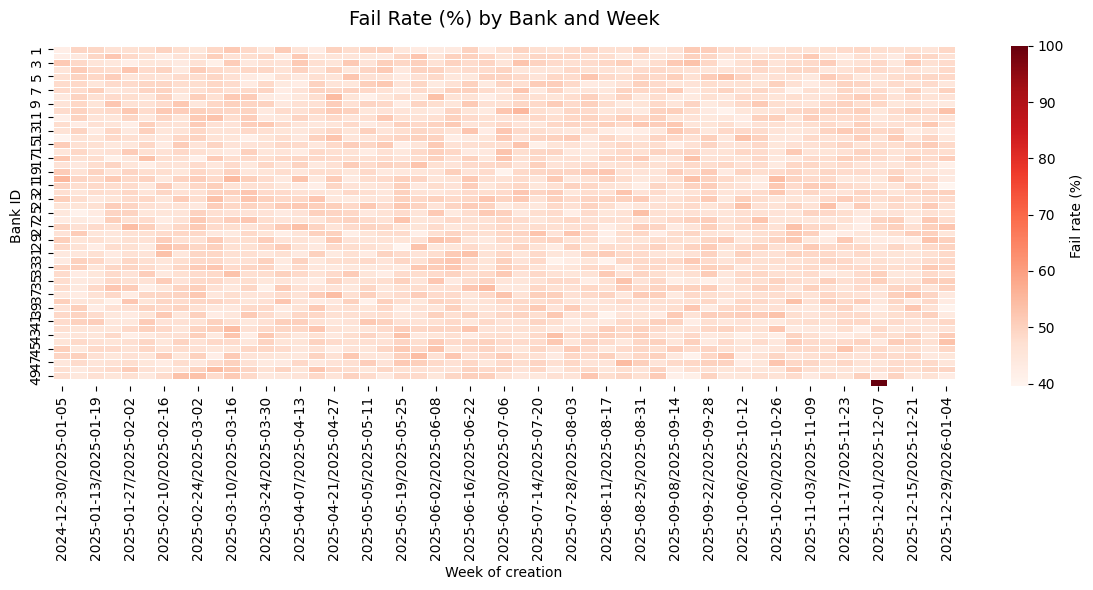

In [21]:
pivot_df = df.pivot_table(values='is_fail', index='bank_id', columns='week', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_df * 100,
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={'label': 'Fail rate (%)'}
)
plt.title('Fail Rate (%) by Bank and Week', fontsize=14, pad=15)
plt.xlabel('Week of creation')
plt.ylabel('Bank ID')
plt.tight_layout()
plt.show()

In [22]:
target_week = df[df['week'] == '2025-12-01/2025-12-07']

fail_stats = target_week.groupby('bank_id')['status'].apply(lambda x: (x == 'fail').mean()).sort_values(ascending=False)
print("Fail rate by bank for this week:")
print(fail_stats.head(5))

Fail rate by bank for this week:
bank_id
777    1.000000
35     0.506303
34     0.503686
26     0.496868
8      0.489978
Name: status, dtype: float64


**Confirmed:** in the week of 2025-12-01/12-07, the highest fail rate belongs to `bank_id == 777` - the same cluster found in section 6, simply resurfaced through a new heatmap.

**Lesson:** this initially looked like a new finding "somewhere in November" - checking the exact dates showed it was the already-known cluster, and the week axis on the heatmap had been misread. Always verify a hunch with an explicit filter and numbers before treating something as a new finding.